# Customer Churn Prediction – Complete Machine Learning Workflow
**Level:** Intermediate | **Task:** Binary classification | **Algorithms:** Logistic Regression, Random Forest, XGBoost

**Group / Student details:** *(add names, roll numbers, division here)*

---
**Requirement checklist (Intermediate level)**

| Requirement | Where in this notebook |
|---|---|
| Real-world dataset | Section 2 – IBM Telco Customer Churn (7,043 customers) |
| Feature selection | Section 5 – Mutual Information ranking + `SelectKBest` inside the pipeline |
| Compare at least 3 ML algorithms | Section 6 – Logistic Regression, Random Forest, XGBoost |
| Suitable evaluation metrics | Section 7 – Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix |
| Explain why performance differs | Section 8 |
| Hyperparameter tuning | Section 9 – GridSearchCV / RandomizedSearchCV |
| Streamlit / web interface | Section 10 – `app.py` |

## 1. Problem Definition
Subscription businesses such as telecom companies lose revenue when customers leave (**churn**). Winning a new customer costs much more than retaining an existing one, so a company wants to identify customers who are *likely to leave* **before** they do, and offer them a targeted retention plan.

**Objective:** Build a supervised machine learning system that predicts whether a customer will discontinue the service (`Churn = Yes/No`) using tenure, usage/service features, billing details and service-related attributes (tech support, security, etc.).

**Type of problem:** Binary classification (the positive class = customer churns).

**Why recall matters:** Missing a customer who is about to leave (false negative) is usually costlier than sending a retention offer to a loyal customer (false positive), so along with accuracy we also track Recall, F1-score and ROC-AUC.

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Dataset
**Source:** IBM Telco Customer Churn dataset (also available on Kaggle as *"Telco Customer Churn"* by BlastChar).
**Records:** 7,043 customers | **Attributes:** 21 columns | **Target variable:** `Churn` (Yes / No)

| Group | Attributes |
|---|---|
| Demographics | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Account / usage | `tenure` (months with company), `Contract`, `PaperlessBilling`, `PaymentMethod` |
| Billing | `MonthlyCharges`, `TotalCharges` |
| Services | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `StreamingTV`, `StreamingMovies` |
| Service-related / support | `TechSupport` (customers without tech support are more likely to leave) |
| Target | `Churn` |

*The notebook loads the CSV from the same folder if present, otherwise downloads it from IBM's public GitHub repository.*

In [2]:
LOCAL_FILE = "WA_Fn-UseC_-Telco-Customer-Churn.csv"   # Kaggle file name (also works with Telco-Customer-Churn.csv)
if not os.path.exists(LOCAL_FILE) and os.path.exists("Telco-Customer-Churn.csv"):
    LOCAL_FILE = "Telco-Customer-Churn.csv"
URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(LOCAL_FILE if os.path.exists(LOCAL_FILE) else URL)
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Preprocessing
Steps performed: fix wrong data types, handle missing values, remove duplicates, check outliers, then encoding and scaling (done inside a `ColumnTransformer` so that nothing from the test set leaks into training).

In [4]:
# 3.1 Data type issue: TotalCharges is stored as text because new customers have a blank value
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTenure of rows with missing TotalCharges:", df.loc[df["TotalCharges"].isnull(), "tenure"].unique())

# These customers have tenure = 0 (brand new, not billed yet) -> TotalCharges = 0 is the logical value
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 3.2 Duplicates (checked on the unique customer ID)
print("\nDuplicate customers:", df.duplicated(subset="customerID").sum())
df = df.drop_duplicates(subset="customerID")

# 3.3 SeniorCitizen is 0/1 -> convert to Yes/No so it is treated as a category
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
print("Final shape:", df.shape)

Missing values per column:
TotalCharges    11
dtype: int64

Tenure of rows with missing TotalCharges: [0]

Duplicate customers: 0
Final shape: (7043, 21)


tenure          outliers (IQR rule): 0
MonthlyCharges  outliers (IQR rule): 0
TotalCharges    outliers (IQR rule): 0


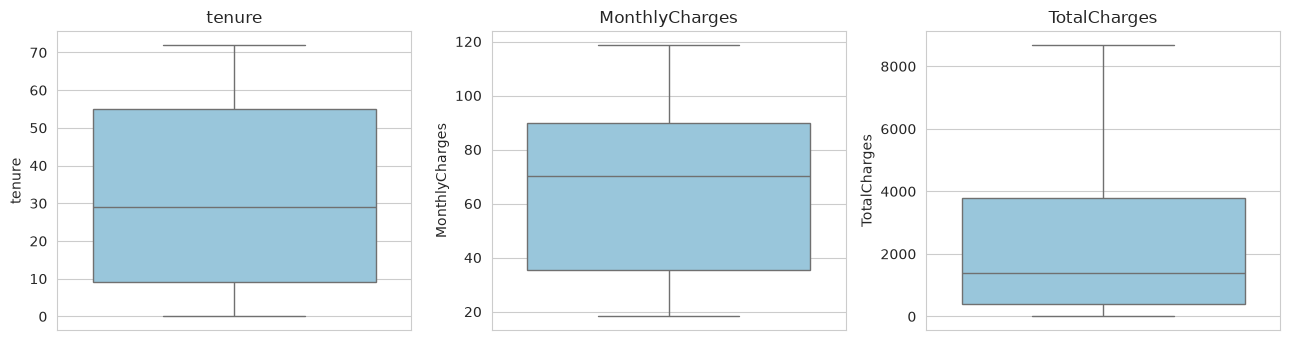

In [5]:
# 3.4 Outlier check using the IQR rule
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    print(f"{c:15s} outliers (IQR rule): {n_out}")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a, c in zip(ax, num_cols):
    sns.boxplot(y=df[c], ax=a, color="#8ecae6"); a.set_title(c)
plt.tight_layout(); plt.show()

**Outlier decision:** The IQR check shows no (or almost no) extreme values, and the values that exist are genuine customers (e.g. long tenure or high bills), so **no rows are removed**. Scaling is still applied for Logistic Regression.

**Encoding & scaling:**
* Categorical columns → **One-Hot Encoding** (no natural order in the categories)
* Numerical columns → **StandardScaler** (needed for Logistic Regression; harmless for tree models)

In [6]:
TARGET = "Churn"
X = df.drop(columns=["customerID", TARGET])
y = (df[TARGET] == "Yes").astype(int)          # 1 = churn, 0 = stays

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

# Stratified split keeps the same churn ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate  train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (5634, 19) | Test: (1409, 19)
Churn rate  train: 0.265 | test: 0.265


## 4. Exploratory Data Analysis (EDA)

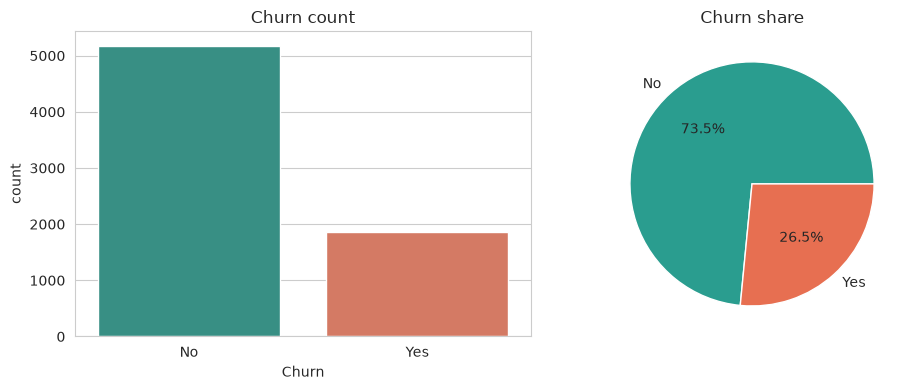

In [7]:
# 4.1 Target distribution (class imbalance check)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=df[TARGET], ax=ax[0], palette=["#2a9d8f", "#e76f51"])
ax[0].set_title("Churn count")
df[TARGET].value_counts().plot.pie(autopct="%1.1f%%", colors=["#2a9d8f", "#e76f51"], ax=ax[1], ylabel="")
ax[1].set_title("Churn share")
plt.tight_layout(); plt.show()

**Observation:** The data is imbalanced (roughly 73% stay vs 27% churn). Accuracy alone would be misleading (a model that always says "No churn" gets ~73%), so we use class weights and look at Precision, Recall, F1 and ROC-AUC.

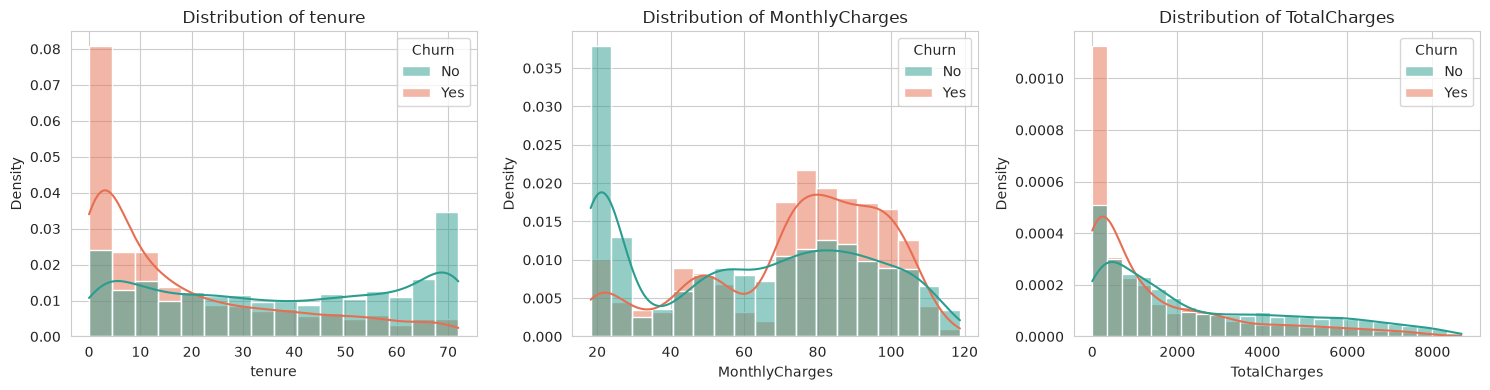

In [8]:
# 4.2 Univariate analysis – numerical features split by churn
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, num_cols):
    sns.histplot(data=df, x=c, hue=TARGET, kde=True, ax=a, palette=["#2a9d8f", "#e76f51"], stat="density", common_norm=False)
    a.set_title(f"Distribution of {c}")
plt.tight_layout(); plt.show()

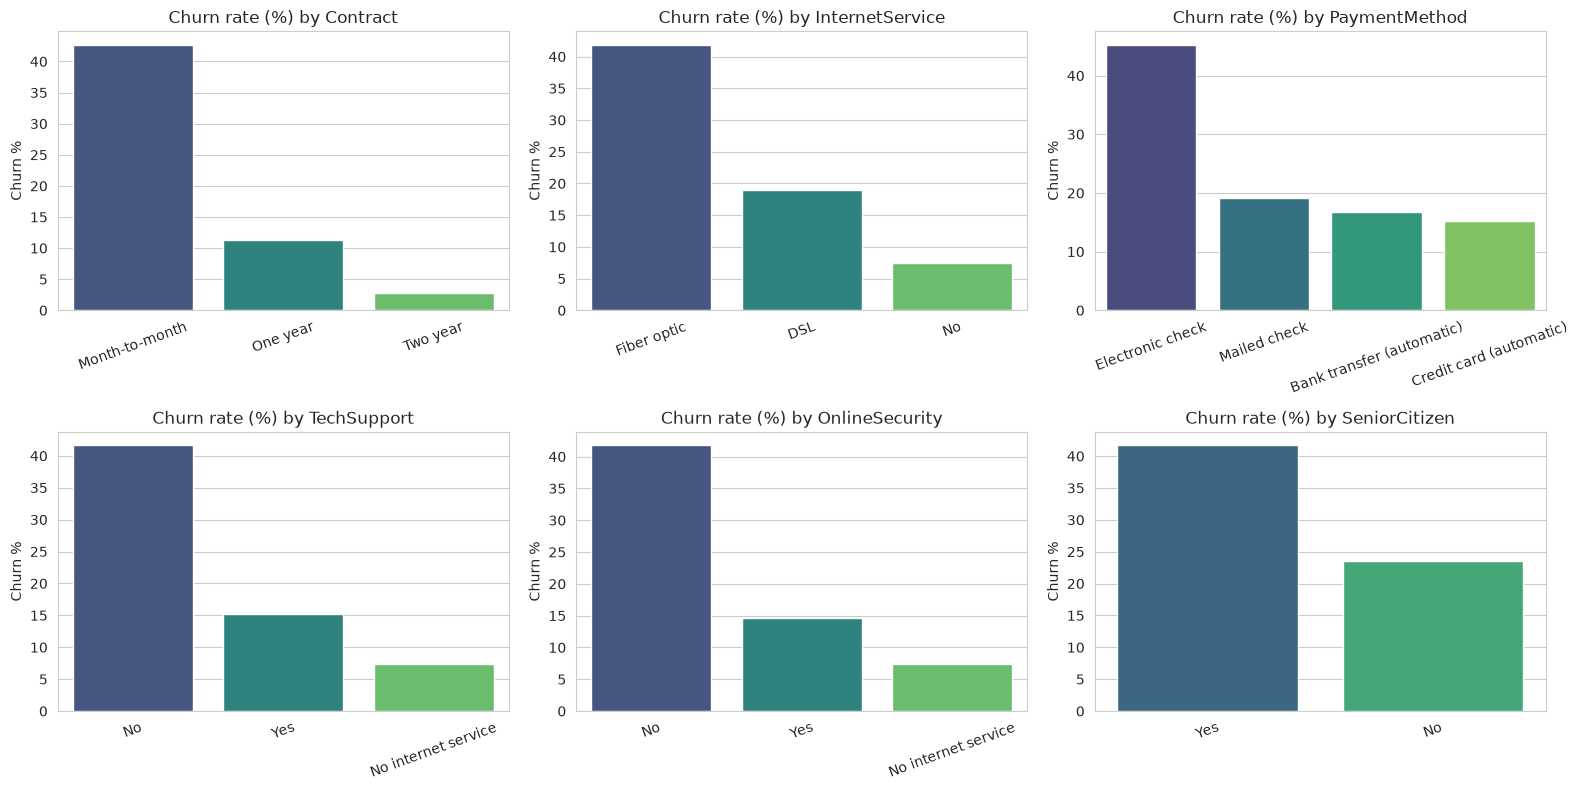

In [9]:
# 4.3 Bivariate analysis – churn rate for each category of the key categorical features
cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "SeniorCitizen"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for a, c in zip(axes.ravel(), cols):
    rate = df.groupby(c)[TARGET].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=a, palette="viridis")
    a.set_title(f"Churn rate (%) by {c}"); a.set_xlabel(""); a.set_ylabel("Churn %")
    a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

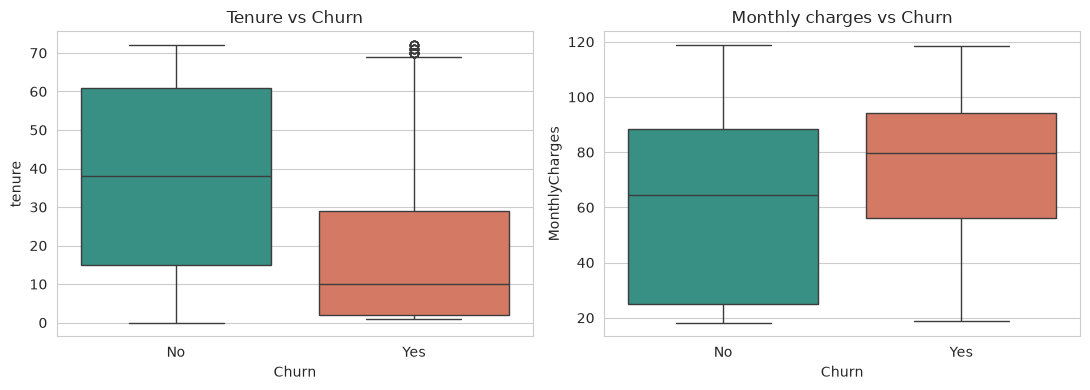

In [10]:
# 4.4 Tenure and monthly charges vs churn
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=df, x=TARGET, y="tenure", ax=ax[0], palette=["#2a9d8f", "#e76f51"]); ax[0].set_title("Tenure vs Churn")
sns.boxplot(data=df, x=TARGET, y="MonthlyCharges", ax=ax[1], palette=["#2a9d8f", "#e76f51"]); ax[1].set_title("Monthly charges vs Churn")
plt.tight_layout(); plt.show()

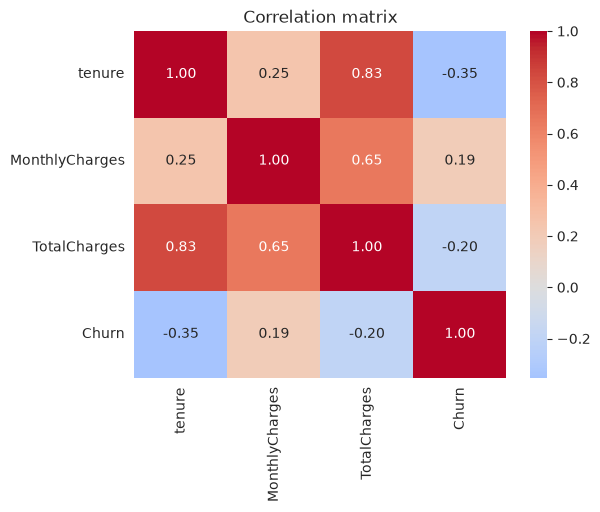

In [11]:
# 4.5 Correlation analysis (numerical features + target)
corr_df = df[num_cols].copy()
corr_df["Churn"] = y
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation matrix"); plt.show()

### Key insights from EDA
* **Contract type** is the strongest signal: month-to-month customers churn far more than one- or two-year contract customers.
* **Short tenure** → high churn risk (most churn happens in the first months).
* **Fibre-optic internet** users and customers paying by **electronic check** churn more.
* Customers **without Tech Support / Online Security** churn more – a service-related factor the company can act on.
* `tenure` and `TotalCharges` are strongly correlated (TotalCharges ≈ tenure × MonthlyCharges), so some redundancy exists → good reason to use feature selection.

## 5. Feature Selection
Two steps:
1. **Mutual Information** is used to *rank* features and understand which ones carry information about churn.
2. **`SelectKBest` (ANOVA F-test)** is placed inside the model pipeline so that only the top *k* features are used; *k* is later tuned during hyperparameter tuning. Doing selection inside the pipeline avoids data leakage during cross-validation.

Total features after encoding: 46


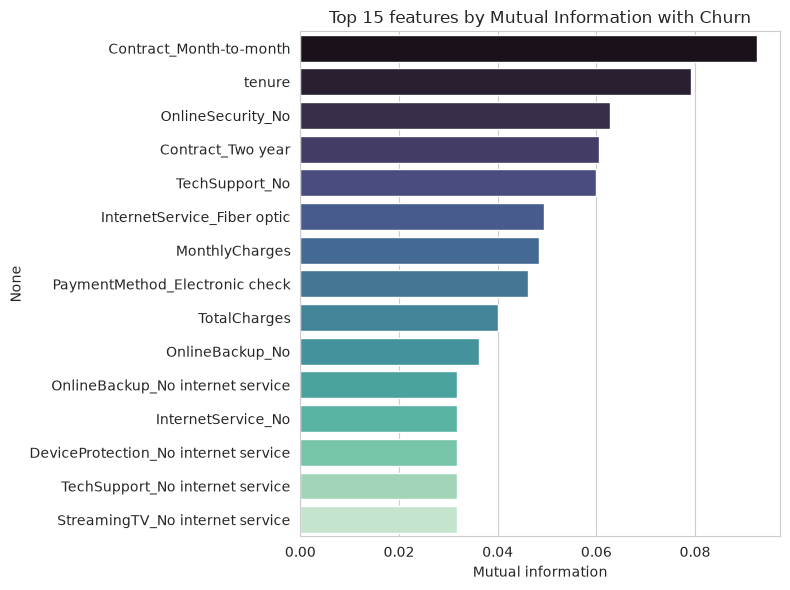

In [12]:
prep_demo = clone(preprocessor).fit(X_train)
Xt = prep_demo.transform(X_train)
feat_names = np.array([n.split("__", 1)[1] for n in prep_demo.get_feature_names_out()])
is_discrete = np.array([n.startswith("cat__") for n in prep_demo.get_feature_names_out()])

mi = mutual_info_classif(Xt, y_train, discrete_features=is_discrete, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=feat_names).sort_values(ascending=False)
print("Total features after encoding:", len(feat_names))

plt.figure(figsize=(8, 6))
sns.barplot(x=mi_s.head(15).values, y=mi_s.head(15).index, palette="mako")
plt.title("Top 15 features by Mutual Information with Churn"); plt.xlabel("Mutual information")
plt.tight_layout(); plt.show()

## 6. Model Development
Three algorithms are compared. They were chosen because they represent three different families:

| Model | Why it is used |
|---|---|
| **Logistic Regression** | Simple, fast, interpretable baseline; models a linear relationship with the log-odds of churn |
| **Random Forest** | Ensemble of decision trees (bagging); captures non-linear effects and feature interactions, robust to noise |
| **XGBoost** | Gradient-boosted trees; builds trees sequentially to correct previous errors; usually the strongest on tabular data |

Class imbalance is handled with `class_weight="balanced"` (LR, RF) and `scale_pos_weight` (XGBoost).

In [13]:
def make_pipe(model, k=25):
    """Preprocessing -> feature selection -> model, all in one pipeline."""
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("select", SelectKBest(f_classif, k=k)),
        ("model", model),
    ])

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, eval_metric="logloss",
                             scale_pos_weight=neg_pos_ratio, random_state=RANDOM_STATE),
}

pipes = {}
for name, m in models.items():
    pipes[name] = make_pipe(m).fit(X_train, y_train)
    print("Trained:", name)

Trained: Logistic Regression


Trained: Random Forest


Trained: XGBoost


## 7. Model Evaluation
Metrics used for classification: **Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix**. A 5-fold cross-validated ROC-AUC on the training data is also reported to check stability.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(name, pipe, with_cv=True):
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }
    if with_cv:
        row["CV ROC-AUC (train)"] = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return row

base_results = pd.DataFrame([evaluate(n, p) for n, p in pipes.items()]).set_index("Model").round(4)
base_results

,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV ROC-AUC (train)
Model,,,,,,
Logistic Regression,0.7353,0.5008,0.7995,0.6159,0.8383,0.8443
Random Forest,0.7523,0.5293,0.6043,0.5643,0.8081,0.8196
XGBoost,0.7473,0.5162,0.7674,0.6172,0.8325,0.8399


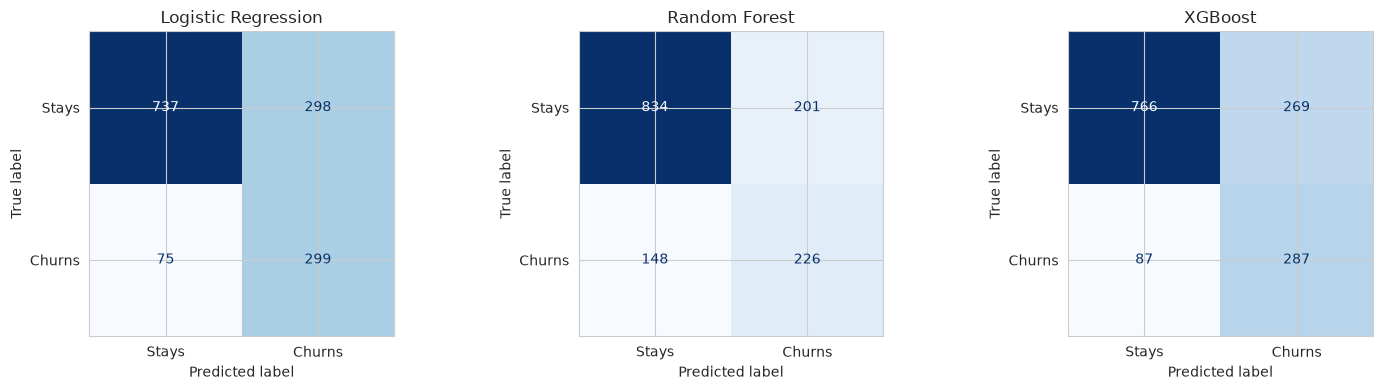

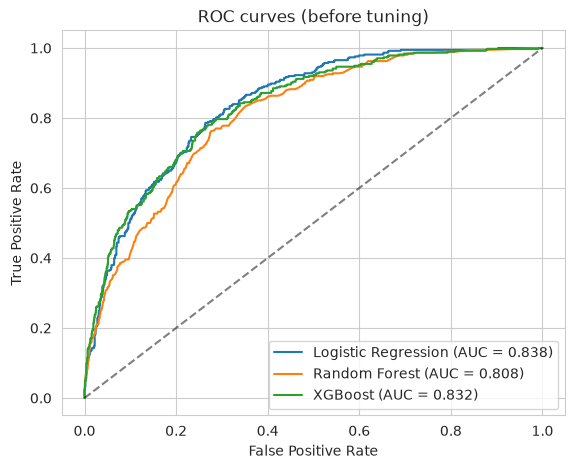

In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, p) in zip(axes, pipes.items()):
    cm = confusion_matrix(y_test, p.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["Stays", "Churns"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

# ROC curves
plt.figure(figsize=(6.5, 5))
for name, p in pipes.items():
    fpr, tpr, _ = roc_curve(y_test, p.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p.predict_proba(X_test)[:, 1]):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC curves (before tuning)")
plt.legend(); plt.show()

## 8. Model Comparison and Why Performance Differs
The results table above (and the tuned results in Section 9) is the evidence for this discussion.

> ✏️ **Before submission:** read the explanation below and adjust the wording to match *your* actual numbers.

**Typical behaviour on this dataset and the reasons:**

1. **Logistic Regression** usually gives a very competitive ROC-AUC. The main churn drivers (contract type, tenure, internet service, monthly charges) act roughly monotonically on the log-odds, so a linear model captures most of the signal. With `class_weight="balanced"` it also achieves the **highest recall** (it catches more churners) but at the cost of lower precision and accuracy.
2. **Random Forest** can model non-linear effects and interactions, but the dataset is small (about 7,000 rows) and mostly binary categorical features, so there is little extra structure to exploit. Un-tuned deep trees can **over-fit** (high training score, lower test score); limiting depth/leaf size during tuning improves it.
3. **XGBoost** corrects errors step by step and is usually the best or tied-best model after tuning. Without tuning, its default depth and learning rate can over-fit slightly; with a lower learning rate, shallow trees and subsampling, it generalises better.
4. **Accuracy vs Recall trade-off:** because only ~27% customers churn, models trained with class weights give up some accuracy to gain recall. For churn, higher recall/F1 is more valuable than raw accuracy.
5. **Small differences** (about 1–2% ROC-AUC) between models mean the features, not the algorithm, are the limiting factor – a common finding on this dataset.

## 9. Hyperparameter Tuning
* Logistic Regression → **GridSearchCV** (small search space: `C`)
* Random Forest and XGBoost → **RandomizedSearchCV** (large search space, 15 random combinations)
* The number of selected features `k` is tuned together with the model parameters.
* Scoring: **ROC-AUC**, 5-fold stratified cross-validation (so the test set is never used for tuning).

*This cell takes a few minutes to run.*

In [16]:
k_options = [15, 20, 25, 30]

searches = {
    "Logistic Regression": GridSearchCV(
        make_pipe(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        {"model__C": [0.01, 0.1, 1, 10], "select__k": k_options},
        cv=cv, scoring="roc_auc", n_jobs=-1),

    "Random Forest": RandomizedSearchCV(
        make_pipe(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
        {"model__n_estimators": [100, 200, 300],
         "model__max_depth": [4, 6, 8, 10, None],
         "model__min_samples_leaf": [1, 3, 5, 10],
         "select__k": k_options},
        n_iter=15, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE),

    "XGBoost": RandomizedSearchCV(
        make_pipe(XGBClassifier(eval_metric="logloss", scale_pos_weight=neg_pos_ratio, random_state=RANDOM_STATE)),
        {"model__n_estimators": [100, 200, 300],
         "model__max_depth": [2, 3, 4, 5],
         "model__learning_rate": [0.01, 0.05, 0.1],
         "model__subsample": [0.7, 0.85, 1.0],
         "model__colsample_bytree": [0.7, 0.85, 1.0],
         "select__k": k_options},
        n_iter=15, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE),
}

tuned = {}
for name, s in searches.items():
    s.fit(X_train, y_train)
    tuned[name] = s.best_estimator_
    print(f"{name}\n  best CV ROC-AUC: {s.best_score_:.4f}\n  best params: {s.best_params_}\n")

Logistic Regression
  best CV ROC-AUC: 0.8446
  best params: {'model__C': 10, 'select__k': 30}



Random Forest
  best CV ROC-AUC: 0.8476
  best params: {'select__k': 20, 'model__n_estimators': 300, 'model__min_samples_leaf': 10, 'model__max_depth': 6}



XGBoost
  best CV ROC-AUC: 0.8492
  best params: {'select__k': 25, 'model__subsample': 0.85, 'model__n_estimators': 100, 'model__max_depth': 2, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}



In [17]:
tuned_results = pd.DataFrame([evaluate(n + " (tuned)", p) for n, p in tuned.items()]).set_index("Model").round(4)
comparison = pd.concat([base_results.rename(index=lambda n: n + " (default)"), tuned_results])
comparison = comparison.sort_values("ROC-AUC", ascending=False)
comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV ROC-AUC (train)
Model,,,,,,
XGBoost (tuned),0.7431,0.5102,0.8048,0.6245,0.8424,0.8492
Random Forest (tuned),0.7417,0.5084,0.8075,0.6240,0.8416,0.8476
Logistic Regression (tuned),0.7331,0.4983,0.8021,0.6148,0.8398,0.8446
Logistic Regression (default),0.7353,0.5008,0.7995,0.6159,0.8383,0.8443
XGBoost (default),0.7473,0.5162,0.7674,0.6172,0.8325,0.8399
Random Forest (default),0.7523,0.5293,0.6043,0.5643,0.8081,0.8196


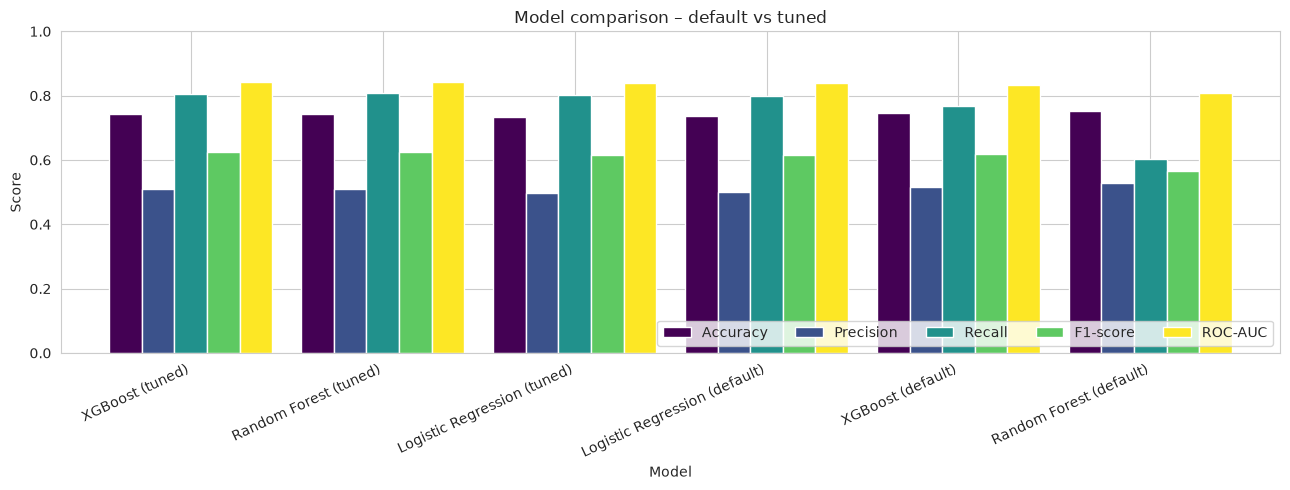

In [18]:
# Visual comparison of all models
comparison[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", figsize=(13, 5), width=0.85, colormap="viridis")
plt.title("Model comparison – default vs tuned"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right"); plt.legend(loc="lower right", ncol=5); plt.tight_layout(); plt.show()

### Selecting the final model
The final model is the **tuned model with the highest test ROC-AUC** (ROC-AUC measures ranking quality independent of the 0.5 threshold, which suits imbalanced churn data). Its confusion matrix and the features it relies on are shown below.

Final model: XGBoost
              precision    recall  f1-score   support

       Stays       0.91      0.72      0.80      1035
      Churns       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



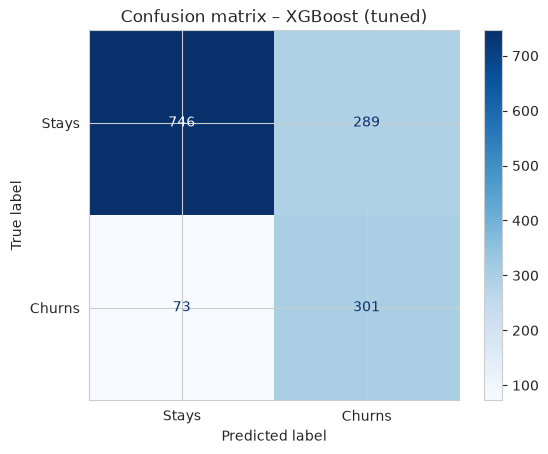

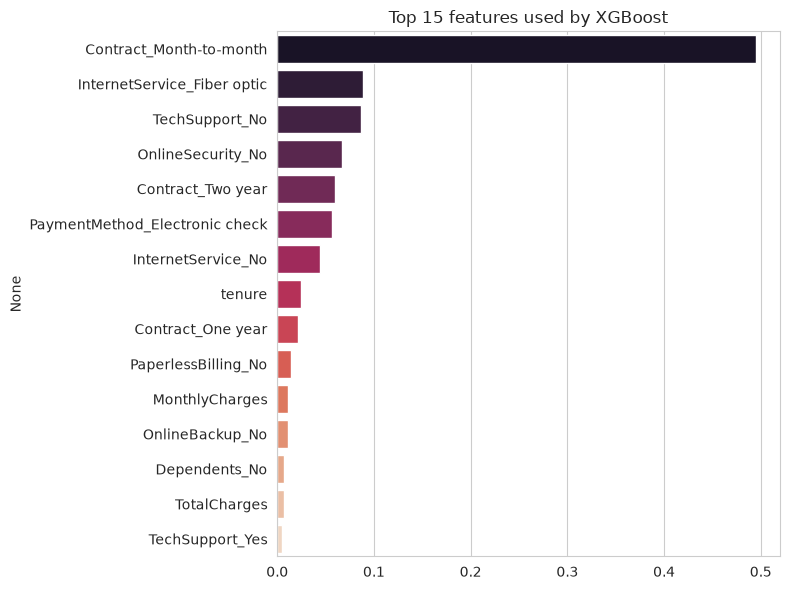

In [19]:
best_name = tuned_results["ROC-AUC"].idxmax().replace(" (tuned)", "")
best_model = tuned[best_name]
print("Final model:", best_name)

# Confusion matrix + classification metrics of the final model
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Stays", "Churns"]))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Stays", "Churns"]).plot(cmap="Blues")
plt.title(f"Confusion matrix – {best_name} (tuned)"); plt.show()

# Features that survived selection and their importance
prep, sel, mdl = best_model.named_steps["prep"], best_model.named_steps["select"], best_model.named_steps["model"]
names = np.array([n.split("__", 1)[1] for n in prep.get_feature_names_out()])[sel.get_support()]
imp = mdl.feature_importances_ if hasattr(mdl, "feature_importances_") else np.abs(mdl.coef_[0])
imp_s = pd.Series(imp, index=names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6)); sns.barplot(x=imp_s.values, y=imp_s.index, palette="rocket")
plt.title(f"Top 15 features used by {best_name}"); plt.tight_layout(); plt.show()

## 10. Deployment / Demonstration
The final pipeline (preprocessing + feature selection + model) is saved with `joblib`. A **Streamlit** app (`app.py`) loads it and lets a user enter customer details to get the churn probability and risk level.

**Run the app:** `streamlit run app.py`

In [20]:
joblib.dump({
    "model": best_model,
    "model_name": best_name,
    "feature_columns": list(X.columns),
}, "churn_model.joblib")
comparison.reset_index().to_csv("model_comparison.csv", index=False)
print("Saved: churn_model.joblib and model_comparison.csv")

Saved: churn_model.joblib and model_comparison.csv


In [21]:
# Prediction demo for a new customer (same code logic the Streamlit app uses)
new_customer = pd.DataFrame([{
    "gender": "Female", "SeniorCitizen": "No", "Partner": "No", "Dependents": "No",
    "tenure": 3, "PhoneService": "Yes", "MultipleLines": "No", "InternetService": "Fiber optic",
    "OnlineSecurity": "No", "OnlineBackup": "No", "DeviceProtection": "No", "TechSupport": "No",
    "StreamingTV": "Yes", "StreamingMovies": "Yes", "Contract": "Month-to-month",
    "PaperlessBilling": "Yes", "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.0, "TotalCharges": 285.0,
}])[list(X.columns)]

prob = best_model.predict_proba(new_customer)[0, 1]
print(f"Churn probability: {prob:.1%} ->", "HIGH RISK – likely to churn" if prob >= 0.5 else "Low risk – likely to stay")

Churn probability: 92.3% -> HIGH RISK – likely to churn


## 11. Conclusion
* A complete ML workflow was implemented: problem definition → dataset → preprocessing → EDA → feature selection → model development → evaluation → comparison → tuning → deployment.
* Three algorithms (Logistic Regression, Random Forest, XGBoost) were compared with proper metrics for an imbalanced classification problem; hyperparameter tuning improved or matched the default models.
* Contract type, tenure, internet service type, monthly charges and lack of tech support / online security are the main churn drivers.
* **Business recommendation:** target month-to-month, short-tenure, fibre-optic customers without tech support with offers such as discounted long-term contracts and free support/security add-ons.

**Limitations:** single dataset, no time dimension, default 0.5 probability threshold. **Future work:** threshold tuning using retention-cost vs customer-value, SMOTE, SHAP explanations, and deploying the Streamlit app online.